In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap
import warnings
warnings.filterwarnings('ignore')


In [2]:
sns.set(style='whitegrid', palette='pastel')

In [3]:
from google.colab import files
upload = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [4]:
ds = pd.read_csv('Titanic-Dataset.csv')
ds.head(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S


In [6]:
ds.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
ds.drop(columns = ['PassengerId', 'Name', 'Cabin', 'Ticket'], inplace = True)

In [8]:
ds['Age'].fillna(ds['Age'].median(), inplace = True)
ds['Embarked'].fillna(ds['Embarked'].mode()[0], inplace = True)

In [9]:
le = LabelEncoder()
ds['Sex'] = le.fit_transform(ds['Sex'])
ds['Embarked'] = le.fit_transform(ds['Embarked'])

In [10]:
ds['FamilySize']= ds['SibSp']+ds['Parch']+1
ds['IsAlone'] = np.where(ds['FamilySize']>1,0,1)
ds.drop(columns = ['SibSp','Parch'],axis = 1, inplace = True)

In [12]:
x = ds.drop('Survived', axis = 1)
y = ds['Survived']

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state = 42)

In [14]:
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [31]:
#train the tuned Random Forest (Black Box)
# I simulate tuned model from Level 2 (best parameters found)
black_box_model = RandomForestClassifier(n_estimators=200, max_depth=6,min_samples_split=5, min_samples_leaf=2,random_state=42)
black_box_model.fit(x_train_scaled, y_train)


RandomForestClassifier(max_depth=6, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

In [16]:
# Evaluate black-box model
y_pred_blackbox = black_box_model.predict(x_test_scaled)
print("Black-Box Model (Tuned Random Forest)")
print("Accuracy:", accuracy_score(y_test, y_pred_blackbox))
print("Classification Report:\n", classification_report(y_test, y_pred_blackbox))

Black-Box Model (Tuned Random Forest)
Accuracy: 0.8044692737430168
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.90      0.84       105
           1       0.82      0.68      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.80      0.80       179



In [17]:
#Build a Surrogate Model (Decision Tree) and Train surrogate model to mimic black-box predictions
y_train_surrogate = black_box_model.predict(x_train_scaled)

In [18]:
surrogate = DecisionTreeClassifier(max_depth = 4, random_state = 42)
surrogate.fit(x_train_scaled, y_train_surrogate)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [19]:
#Evaluate surrogate model on test set (vs black-box predictions)
y_pred_surrogate = surrogate.predict(x_test_scaled)

In [20]:
print("\n Surrogate Model (Decision Tree) ")
print("Agreement with Black-Box:", accuracy_score(y_pred_blackbox, y_pred_surrogate))
print("Surrogate Accuracy (vs true labels):", accuracy_score(y_test, y_pred_surrogate))
print("Classification Report:\n", classification_report(y_test, y_pred_surrogate))


 Surrogate Model (Decision Tree) 
Agreement with Black-Box: 0.9497206703910615
Surrogate Accuracy (vs true labels): 0.7988826815642458
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.78       179
weighted avg       0.80      0.80      0.79       179



In [32]:
results = pd.DataFrame({
    'Model': ['Black-Box RF', 'Surrogate Tree'],
    'Accuracy_vs_True': [accuracy_score(y_test, y_pred_blackbox),accuracy_score(y_test, y_pred_surrogate)],
    'Agreement_with_BlackBox': [1.0, accuracy_score(y_pred_blackbox, y_pred_surrogate)]
})
print("\nComparative Results")
print(results)


Comparative Results
            Model  Accuracy_vs_True  Agreement_with_BlackBox
0    Black-Box RF          0.804469                 1.000000
1  Surrogate Tree          0.798883                 0.949721


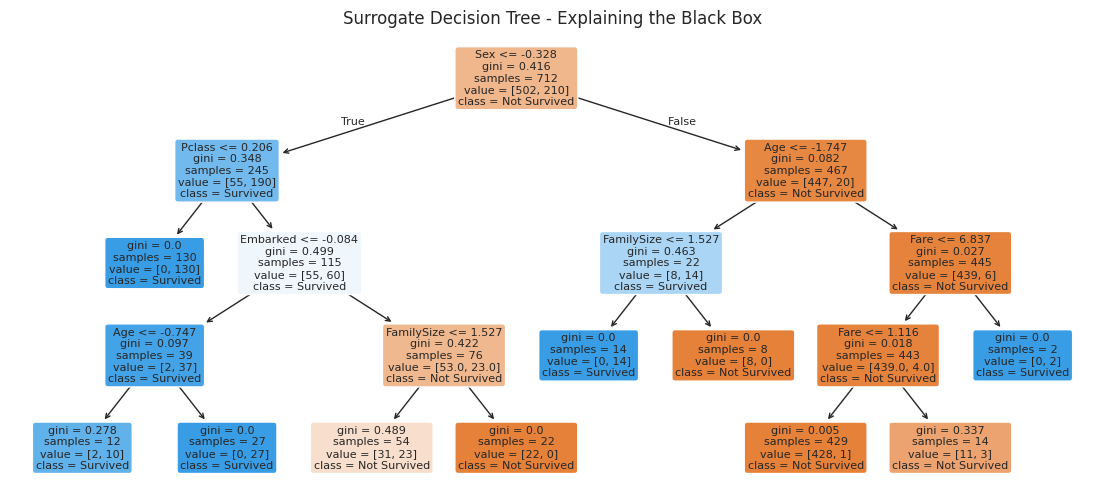

In [33]:
#Visualize surrogate model

plt.figure(figsize=(14,6))
plot_tree(surrogate, feature_names=x.columns, class_names=['Not Survived','Survived'], filled=True, rounded=True, fontsize=8)
plt.title("Surrogate Decision Tree - Explaining the Black Box")
plt.show()

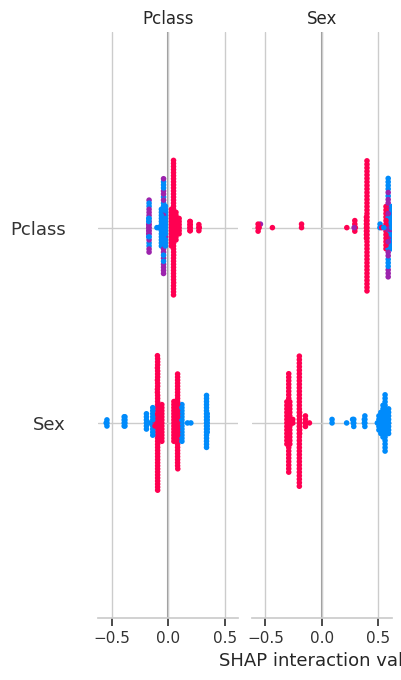

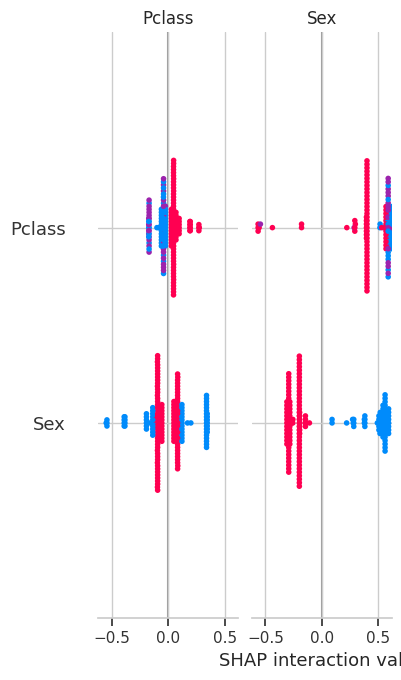

In [25]:
#Explain surrogate using SHAP
# --------------------------
explainer = shap.TreeExplainer(surrogate)
shap_values = explainer.shap_values(x_test_scaled)

# Global feature importance
shap.summary_plot(shap_values, x_test, feature_names=x.columns, plot_size=(8,5))
shap.summary_plot(shap_values, x_test, plot_type='bar', feature_names=x.columns)


In [34]:
#Analyze Bias or Vulnerabilities

# Example: check difference in prediction rates for men vs women
pred_df = x_test.copy()
pred_df['TrueLabel'] = y_test
pred_df['RF_Pred'] = y_pred_blackbox
pred_df['Tree_Pred'] = y_pred_surrogate
pred_df['Sex'] = ds.loc[x_test.index, 'Sex']

bias_check = pred_df.groupby('Sex')[['RF_Pred', 'Tree_Pred']].mean()
bias_check.index = ['Female (0)', 'Male (1)']
print("\n Prediction Bias Check")
print(bias_check)


 Prediction Bias Check
             RF_Pred  Tree_Pred
Female (0)  0.855072   0.826087
Male (1)    0.018182   0.009091
